In [1]:
# !pip install 'zarr<3'
# !pip install timm


In [2]:
# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Specify GPU 0 (out of 4 available GPUs)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))
print(f"✅ Working directory: {os.getcwd()}")
print(f"✅ Using GPU: {os.environ.get('CUDA_VISIBLE_DEVICES', 'Not set')}")

✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest
✅ Using GPU: 0


In [3]:
# Cell 3: Import and create dataloaders
from dataset import Config, create_dataloaders

# Just use the correct relative path from your working directory
config = Config("configs/training/newmethod.yaml")  # Note: "configs" not "config"
config.print_config()

train_loader, val_loader, test_loader = create_dataloaders(config)
print("\n✅ Ready to use!")

✅ CRC Dataset Package v1.0.0 loaded
CRC DATASET CONFIGURATION
Config File: configs/training/newmethod.yaml
Zarr Base: /rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/cpm15
Cache: Disabled
Strategy: memory

📊 Data Splits:
  Train: 3 samples
  Val: 3 samples
  Test: 4 samples

🔄 DataLoader:
  Batch Size: 4
  Num Workers: 16
  Pin Memory: True

🎨 Augmentation:
  Training: True
  Probability: 1.0

🎯 HV Maps:
  Generate: True
  Method: pannuke
  HE Nuclei: True
  HE Cells: True
  MIF Nuclei: True
  MIF Cells: True

🔍 Filtering:
  Min Instances: 0
  Filter Empty: True

CREATING DATALOADERS
Strategy: memory
Use Cache: False
Batch Size: 4
Num Workers: 16
Train split: 0 CRC + 0 Xenium + 0 TissueNet + 0 PanNuke + 0 Lizard + 0 MoNuSeg + 0 MoNuSAC + 0 TNBC + 0 NuInsSeg + 0 CryoNuSeg + 0 BC + 0 CoNSeP + 0 Kumar + 0 CPM17 + 1 CPM15 + 1 HE_DSB2018 + 1 Fluo_DSB2018 + 0 PanopTILs
Val   split: 0 CRC + 0 Xenium + 0 TissueNet + 0 PanNuke + 0 Lizard + 0 MoNuSeg + 0 MoNuSAC + 0 TNBC + 0 NuInsSeg + 

## Flex model CPM15 and panoptils

In [6]:
import torch
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from metrics import get_fast_pq, aggregated_jaccard_index
from vitaminp import VitaminPFlex, SimplePreprocessing, prepare_he_input, prepare_mif_input
from postprocessing import process_model_outputs

# ==========================================
# 1. CONFIGURATION: DATASET MODALITIES
# ==========================================
DATASET_MODALITIES = {
    # MIF Only Datasets
    'fluorescence_dsb2018': {'he_nuclei': False, 'he_cell': False, 'mif_nuclei': True,  'mif_cell': False},
    
    # H&E Only Datasets
    'he_dsb2018': {'he_nuclei': True,  'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'cpm15':      {'he_nuclei': True,  'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'panoptils':      {'he_nuclei': True,  'he_cell': False, 'mif_nuclei': False, 'mif_cell': False}

}

# ==========================================
# 2. SETUP & TTA HELPERS
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("\n📦 Loading model...")
model = VitaminPFlex(model_size='large').to(device)
checkpoint_path = "checkpoints/vitamin_p_flex_large_fold32_hv4_mag_best.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()
preprocessor = SimplePreprocessing()
print(f"✅ Model loaded")

# Structure: metrics[dataset][mode][metric_name] -> list
dataset_metrics = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
dataset_counts = defaultdict(int)

def get_tta_outputs(model, img_tensor):
    """
    Runs inference 3 times (Orig, HFlip, VFlip) and returns 
    both the Original output (Base) and the Averaged output (TTA).
    """
    # 1. Original
    out_orig = model(img_tensor)

    # 2. H-Flip
    img_h = torch.flip(img_tensor, [3])
    out_h = model(img_h)
    # De-augment H
    for k in out_h.keys():
        out_h[k] = torch.flip(out_h[k], [3])
        if 'hv' in k: out_h[k][:, 0, :, :] *= -1 

    # 3. V-Flip
    img_v = torch.flip(img_tensor, [2])
    out_v = model(img_v)
    # De-augment V
    for k in out_v.keys():
        out_v[k] = torch.flip(out_v[k], [2])
        if 'hv' in k: out_v[k][:, 1, :, :] *= -1 

    # Aggregate
    out_avg = {}
    for k in out_orig.keys():
        stack = torch.stack([out_orig[k], out_h[k], out_v[k]])
        out_avg[k] = torch.mean(stack, dim=0)
        
    return out_orig, out_avg

# ==========================================
# 3. EVALUATION LOOP
# ==========================================
print("\n🚀 Starting Global Evaluation (Comparing Base vs. TTA)...")

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Processing Test Set"):
        
        sources = batch.get('dataset_source', [])
        
        # --- Prepare Inputs ---
        
        # 1. H&E Input (Prepare if ANY dataset needs it, or just prepare always to be safe/simple)
        # Optimization: We can check if any source needs H&E, but for now we run it standard.
        he_img = prepare_he_input(batch['he_image'].to(device))
        he_img = preprocessor.percentile_normalize(he_img)
        
        # 2. MIF Input (Check if ANY source in this batch requires MIF)
        has_mif_in_batch = False
        for s in sources:
            if s in DATASET_MODALITIES:
                if DATASET_MODALITIES[s]['mif_nuclei'] or DATASET_MODALITIES[s]['mif_cell']:
                    has_mif_in_batch = True
                    break
        
        mif_img = None
        if has_mif_in_batch:
            mif_img = prepare_mif_input(batch['mif_image'].to(device))
            mif_img = preprocessor.percentile_normalize(mif_img)
        
        # --- Run Inference (Get BOTH Base and TTA) ---
        out_he_base, out_he_tta = get_tta_outputs(model, he_img)
        
        out_mif_base, out_mif_tta = (None, None), (None, None)
        if has_mif_in_batch:
            out_mif_base, out_mif_tta = get_tta_outputs(model, mif_img)

        # Iterate samples in batch
        batch_size = len(sources)
        for i in range(batch_size):
            ds_name = sources[i]
            if ds_name not in DATASET_MODALITIES: continue
                
            dataset_counts[ds_name] += 1
            mods = DATASET_MODALITIES[ds_name]

            # Helper to calculate and store for a specific mode (Base or TTA)
            def calc_sample_metrics(outputs, mode_name, modality_type):
                if outputs is None: return

                prefix = modality_type # 'he' or 'mif'

                # NUCLEI
                # Check if dataset wants this metric AND if output contains it
                if mods.get(f'{prefix}_nuclei', False):
                    if f'{prefix}_nuclei_seg' in outputs:
                        pred, _, _ = process_model_outputs(
                            outputs[f'{prefix}_nuclei_seg'][i, 0].cpu().numpy(),
                            outputs[f'{prefix}_nuclei_hv'][i, 0].cpu().numpy(),
                            outputs[f'{prefix}_nuclei_hv'][i, 1].cpu().numpy()
                        )
                        gt = batch[f'{prefix}_nuclei_instance'][i].cpu().numpy()
                        if gt.max() > 0:
                            pq, _, _ = get_fast_pq(gt, pred)
                            aji = aggregated_jaccard_index(gt, pred)
                            dataset_metrics[ds_name][mode_name][f'{prefix}_nuclei_pq'].append(pq)
                            dataset_metrics[ds_name][mode_name][f'{prefix}_nuclei_aji'].append(aji)

                # CELL
                if mods.get(f'{prefix}_cell', False):
                    if f'{prefix}_cell_seg' in outputs:
                        pred, _, _ = process_model_outputs(
                            outputs[f'{prefix}_cell_seg'][i, 0].cpu().numpy(),
                            outputs[f'{prefix}_cell_hv'][i, 0].cpu().numpy(),
                            outputs[f'{prefix}_cell_hv'][i, 1].cpu().numpy()
                        )
                        gt = batch[f'{prefix}_cell_instance'][i].cpu().numpy()
                        if gt.max() > 0:
                            pq, _, _ = get_fast_pq(gt, pred)
                            aji = aggregated_jaccard_index(gt, pred)
                            dataset_metrics[ds_name][mode_name][f'{prefix}_cell_pq'].append(pq)
                            dataset_metrics[ds_name][mode_name][f'{prefix}_cell_aji'].append(aji)

            # Store stats for Base
            calc_sample_metrics(out_he_base, 'base', 'he')
            if has_mif_in_batch: 
                calc_sample_metrics(out_mif_base, 'base', 'mif')
            
            # Store stats for TTA
            calc_sample_metrics(out_he_tta, 'tta', 'he')
            if has_mif_in_batch: 
                calc_sample_metrics(out_mif_tta, 'tta', 'mif')

# ==========================================
# 4. REPORTING (COMPARATIVE)
# ==========================================
print("\n" + "="*130)
print("📊 FINAL EVALUATION REPORT: BASE vs TTA")
print("="*130)

sorted_datasets = sorted(dataset_metrics.keys())

for ds_name in sorted_datasets:
    count = dataset_counts[ds_name]
    metrics = dataset_metrics[ds_name]
    
    print(f"\n📁 DATASET: {ds_name.upper()} (Tiles: {count})")
    print(f"{'Modality':<20} | {'Base PQ':<15} | {'TTA PQ':<15} | {'Δ PQ':<8} | {'Base AJI':<15} | {'TTA AJI':<15}")
    print("-" * 130)
    
    check_list = [
        ('H&E Nuclei', 'he_nuclei'),
        ('H&E Cells',  'he_cell'),
        ('MIF Nuclei', 'mif_nuclei'),
        ('MIF Cells',  'mif_cell')
    ]
    
    found_any = False
    for label, key in check_list:
        base_pq_list = metrics['base'].get(f'{key}_pq', [])
        tta_pq_list = metrics['tta'].get(f'{key}_pq', [])
        
        if len(base_pq_list) > 0:
            found_any = True
            b_pq = np.mean(base_pq_list)
            b_pq_std = np.std(base_pq_list)
            t_pq = np.mean(tta_pq_list)
            t_pq_std = np.std(tta_pq_list)
            d_pq = t_pq - b_pq
            
            b_aji = np.mean(metrics['base'][f'{key}_aji'])
            b_aji_std = np.std(metrics['base'][f'{key}_aji'])
            t_aji = np.mean(metrics['tta'][f'{key}_aji'])
            t_aji_std = np.std(metrics['tta'][f'{key}_aji'])
            
            sym = "+" if d_pq >= 0 else ""
            
            print(f"{label:<20} | {b_pq:.4f}±{b_pq_std:.4f} | {t_pq:.4f}±{t_pq_std:.4f} | {sym}{d_pq:.4f}   | {b_aji:.4f}±{b_aji_std:.4f} | {t_aji:.4f}±{t_aji_std:.4f}")
            
    if not found_any:
        print("  (No valid metrics computed for this dataset)")

    print("-" * 130)

print("\n✅ All datasets processed.")

Using device: cuda

📦 Loading model...
✓ VitaminPFlex PRO initialized with large backbone
  + ASPP Bridge Active (Context Enhancement)
  + CoordConv Heads Active (Spatial Awareness)
✅ Model loaded

🚀 Starting Global Evaluation (Comparing Base vs. TTA)...


Processing Test Set: 100%|██████████| 1737/1737 [1:15:35<00:00,  2.61s/it]


📊 FINAL EVALUATION REPORT: BASE vs TTA

📁 DATASET: CPM15 (Tiles: 46)
Modality             | Base PQ         | TTA PQ          | Δ PQ     | Base AJI        | TTA AJI        
----------------------------------------------------------------------------------------------------------------------------------
H&E Nuclei           | 0.6604±0.0929 | 0.6684±0.0938 | +0.0079   | 0.6511±0.1049 | 0.6600±0.1004
----------------------------------------------------------------------------------------------------------------------------------

📁 DATASET: FLUORESCENCE_DSB2018 (Tiles: 53)
Modality             | Base PQ         | TTA PQ          | Δ PQ     | Base AJI        | TTA AJI        
----------------------------------------------------------------------------------------------------------------------------------
MIF Nuclei           | 0.5038±0.2838 | 0.5055±0.2841 | +0.0017   | 0.5477±0.2455 | 0.5446±0.2546
------------------------------------------------------------------------------------------

## HE DSB2018


🔬 Finding he_dsb2018 samples...
✅ Found 15 he_dsb2018 samples total
Using device: cuda

📦 Loading model...
✓ VitaminPFlex PRO initialized with large backbone
  + ASPP Bridge Active (Context Enhancement)
  + CoordConv Heads Active (Spatial Awareness)
✅ Model loaded

🎲 Selected Random he_dsb2018 Sample (Batch 19, Index 0)
🖼️ Processing Sample: TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500_xmin-1024_ymin-0_xmax-2048_ymax-1024 (Source: panoptils)

📊 METRIC VERIFICATION

🔍 --- H&E NUCLEI METRIC EXPLANATION ---
  Ground Truth: 151 | Predicted: 150
  TP: 117 | FP: 33 | FN: 34
  SQ: 0.7428 | DQ: 0.7774 | PQ: 0.5775

❌ --- H&E CELLS INVALID ---
   Reason: GT is empty, but model predicted 162 instances (Pure False Positives).

⚠️ --- MIF NUCLEI SKIPPED ---
   Reason: Both Ground Truth and Prediction are empty (Missing Modality).

⚠️ --- MIF CELLS SKIPPED ---
   Reason: Both Ground Truth and Prediction are empty (Missing Modality).

ℹ️ Note: MIF image has 2 channels. Collapsing to mean intensi

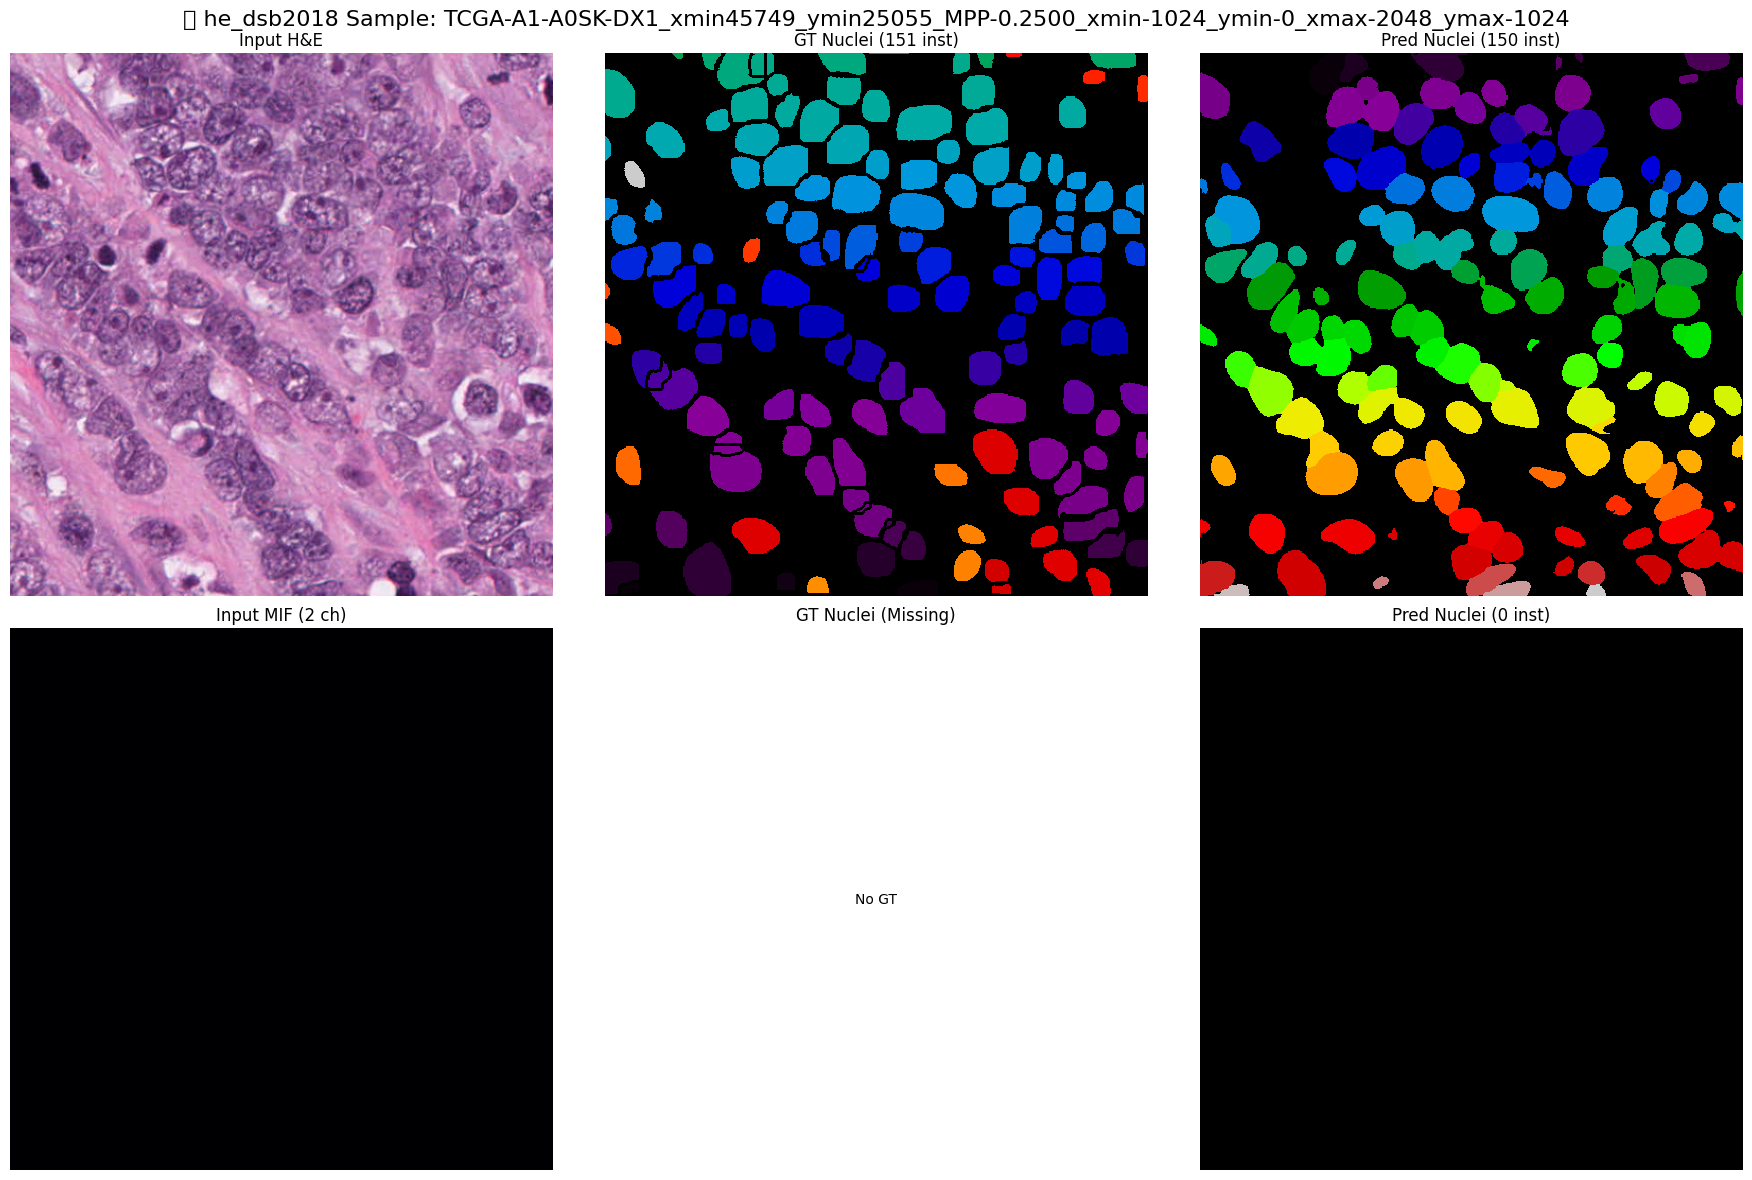


✅ Visualization generated and saved as 'he_dsb2018_visualization.png'


In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
from metrics import get_fast_pq, aggregated_jaccard_index
from vitaminp import VitaminPFlex, SimplePreprocessing, prepare_he_input, prepare_mif_input
from postprocessing import process_model_outputs

# ==========================================
# 1. FIND HE_DSB2018 SAMPLES
# ==========================================
print("\n🔬 Finding he_dsb2018 samples...")
he_dsb2018_samples = []

# Search through test_loader batches for he_dsb2018 samples
for batch_idx, batch in enumerate(test_loader):
    sources = batch.get('dataset_source', [])
    for i, source in enumerate(sources):
        if source == 'panoptils':
            he_dsb2018_samples.append((batch_idx, i, batch))
    
    # Stop if we found enough
    if len(he_dsb2018_samples) >= 12:
        break

print(f"✅ Found {len(he_dsb2018_samples)} he_dsb2018 samples total")


# ==========================================
# 2. SETUP & TTA HELPERS
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("\n📦 Loading model...")
model = VitaminPFlex(model_size='large').to(device)
checkpoint_path = "checkpoints/vitamin_p_flex_large_fold32_hv4_mag_best.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()
preprocessor = SimplePreprocessing()
print(f"✅ Model loaded")
# ==========================================
# 2. HELPER FUNCTION: EXPLAINABLE METRICS
# ==========================================
def calculate_and_explain_pq(gt_map, pred_map, type_name="Nuclei"):
    """
    Calculates PQ with ZERO DIVISION PROTECTION.
    """
    gt_instances = np.unique(gt_map)
    gt_instances = gt_instances[gt_instances != 0]
    
    pred_instances = np.unique(pred_map)
    pred_instances = pred_instances[pred_instances != 0]

    # CHECK: If both are empty, skip
    if len(gt_instances) == 0 and len(pred_instances) == 0:
        print(f"\n⚠️ --- {type_name.upper()} SKIPPED ---")
        print("   Reason: Both Ground Truth and Prediction are empty (Missing Modality).")
        return 0.0, 0.0, 0.0

    # CHECK: If GT is empty but Prediction is not
    if len(gt_instances) == 0 and len(pred_instances) > 0:
        print(f"\n❌ --- {type_name.upper()} INVALID ---")
        print(f"   Reason: GT is empty, but model predicted {len(pred_instances)} instances (Pure False Positives).")
        return 0.0, 0.0, 0.0

    tp_count = 0
    iou_sum = 0
    matched_gt = set()
    matched_pred = set()

    for pred_id in pred_instances:
        pred_mask = (pred_map == pred_id)
        overlap_gt_ids = np.unique(gt_map[pred_mask])
        overlap_gt_ids = overlap_gt_ids[overlap_gt_ids != 0]
        
        best_iou = 0
        best_gt = None
        
        for gt_id in overlap_gt_ids:
            gt_mask = (gt_map == gt_id)
            intersection = np.logical_and(pred_mask, gt_mask).sum()
            union = np.logical_or(pred_mask, gt_mask).sum()
            iou = intersection / union
            
            if iou > 0.5 and iou > best_iou:
                best_iou = iou
                best_gt = gt_id
        
        if best_gt is not None and best_gt not in matched_gt:
            tp_count += 1
            iou_sum += best_iou
            matched_gt.add(best_gt)
            matched_pred.add(pred_id)

    fp_count = len(pred_instances) - len(matched_pred)
    fn_count = len(gt_instances) - len(matched_gt)

    denominator = tp_count + 0.5 * fp_count + 0.5 * fn_count
    dq = tp_count / denominator if denominator > 0 else 0.0
    sq = iou_sum / tp_count if tp_count > 0 else 0.0
    pq = sq * dq

    print(f"\n🔍 --- {type_name.upper()} METRIC EXPLANATION ---")
    print(f"  Ground Truth: {len(gt_instances)} | Predicted: {len(pred_instances)}")
    print(f"  TP: {tp_count} | FP: {fp_count} | FN: {fn_count}")
    print(f"  SQ: {sq:.4f} | DQ: {dq:.4f} | PQ: {pq:.4f}")
    
    return pq, dq, sq

# ==========================================
# 3. SELECT A RANDOM HE_DSB2018 SAMPLE
# ==========================================
if len(he_dsb2018_samples) == 0:
    print("❌ No he_dsb2018 samples found!")
    exit()

# Select random sample
batch_idx, sample_idx, selected_batch = random.choice(he_dsb2018_samples)
print(f"\n🎲 Selected Random he_dsb2018 Sample (Batch {batch_idx}, Index {sample_idx})")

sample_name = selected_batch['sample_name'][sample_idx]
dataset_source = selected_batch['dataset_source'][sample_idx]
print(f"🖼️ Processing Sample: {sample_name} (Source: {dataset_source})")

# ==========================================
# 4. INFERENCE & VISUALIZATION
# ==========================================
with torch.no_grad():
    # --- PREPARE DATA ---
    he_img_raw = selected_batch['he_image'][sample_idx:sample_idx+1].to(device)
    he_img = prepare_he_input(he_img_raw)
    he_img = preprocessor.percentile_normalize(he_img)
    
    mif_img_raw = selected_batch['mif_image'][sample_idx:sample_idx+1].to(device)
    mif_img = prepare_mif_input(mif_img_raw)
    mif_img = preprocessor.percentile_normalize(mif_img)

    # --- RUN MODEL ---
    outputs_he = model(he_img)
    outputs_mif = model(mif_img)

    # --- POST PROCESSING ---
    # Helper to get prediction
    def get_pred(outputs, type_prefix):
        return process_model_outputs(
            outputs[f'{type_prefix}_seg'][0, 0].cpu().numpy(),
            outputs[f'{type_prefix}_hv'][0, 0].cpu().numpy(),
            outputs[f'{type_prefix}_hv'][0, 1].cpu().numpy()
        )[0]

    he_nuclei_pred = get_pred(outputs_he, 'he_nuclei')
    he_cell_pred = get_pred(outputs_he, 'he_cell')
    mif_nuclei_pred = get_pred(outputs_mif, 'mif_nuclei')
    mif_cell_pred = get_pred(outputs_mif, 'mif_cell')

    # Get GT
    he_nuclei_gt = selected_batch['he_nuclei_instance'][sample_idx].cpu().numpy()
    he_cell_gt = selected_batch['he_cell_instance'][sample_idx].cpu().numpy()
    mif_nuclei_gt = selected_batch['mif_nuclei_instance'][sample_idx].cpu().numpy()
    mif_cell_gt = selected_batch['mif_cell_instance'][sample_idx].cpu().numpy()

    # --- VERIFY METRICS ---
    print("\n" + "="*50)
    print("📊 METRIC VERIFICATION")
    print("="*50)
    
    calculate_and_explain_pq(he_nuclei_gt, he_nuclei_pred, "H&E Nuclei")
    calculate_and_explain_pq(he_cell_gt, he_cell_pred, "H&E Cells")
    calculate_and_explain_pq(mif_nuclei_gt, mif_nuclei_pred, "MIF Nuclei")
    calculate_and_explain_pq(mif_cell_gt, mif_cell_pred, "MIF Cells")

    # ==========================================
    # 5. ROBUST PLOTTING
    # ==========================================
    def to_plot(img_tensor):
        img = img_tensor.cpu().numpy().transpose(1, 2, 0)
        if img.max() > 1: img = img / 255.0
        return np.clip(img, 0, 1)

    # Prepare MIF display
    mif_raw_np = selected_batch['mif_image'][sample_idx].cpu().numpy() # Shape: (C, H, W)
    C, H, W = mif_raw_np.shape
    
    if C == 3:
        mif_disp = mif_raw_np.transpose(1, 2, 0)
    elif C == 1:
        mif_disp = mif_raw_np[0]
    else:
        print(f"\nℹ️ Note: MIF image has {C} channels. Collapsing to mean intensity for display.")
        mif_disp = np.mean(mif_raw_np, axis=0)

    # Check existence of GT
    has_he_nuc = he_nuclei_gt.max() > 0
    has_mif_nuc = mif_nuclei_gt.max() > 0
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    plt.suptitle(f"🔬 he_dsb2018 Sample: {sample_name}", fontsize=16)

    # --- ROW 1: H&E ---
    axes[0, 0].imshow(to_plot(selected_batch['he_image'][sample_idx]))
    axes[0, 0].set_title("Input H&E")
    
    if has_he_nuc:
        axes[0, 1].imshow(he_nuclei_gt, cmap='nipy_spectral', interpolation='nearest')
        axes[0, 1].set_title(f"GT Nuclei ({len(np.unique(he_nuclei_gt))-1} inst)")
    else:
        axes[0, 1].text(0.5, 0.5, "No GT", ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title("GT Nuclei (Missing)")
        
    axes[0, 2].imshow(he_nuclei_pred, cmap='nipy_spectral', interpolation='nearest')
    axes[0, 2].set_title(f"Pred Nuclei ({len(np.unique(he_nuclei_pred))-1} inst)")

    # --- ROW 2: MIF ---
    axes[1, 0].imshow(mif_disp, cmap='magma')
    axes[1, 0].set_title(f"Input MIF ({C} ch)")
    
    if has_mif_nuc:
        axes[1, 1].imshow(mif_nuclei_gt, cmap='nipy_spectral', interpolation='nearest')
        axes[1, 1].set_title(f"GT Nuclei ({len(np.unique(mif_nuclei_gt))-1} inst)")
    else:
        axes[1, 1].text(0.5, 0.5, "No GT", ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title("GT Nuclei (Missing)")
        
    axes[1, 2].imshow(mif_nuclei_pred, cmap='nipy_spectral', interpolation='nearest')
    axes[1, 2].set_title(f"Pred Nuclei ({len(np.unique(mif_nuclei_pred))-1} inst)")

    for ax in axes.flatten():
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('he_dsb2018_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n✅ Visualization generated and saved as 'he_dsb2018_visualization.png'")

2026-02-17 03:22:11 - WSIPredictor - INFO - WSIPredictor initialized:
2026-02-17 03:22:11 - WSIPredictor - INFO -   Device: cuda
2026-02-17 03:22:11 - WSIPredictor - INFO -   Model type: VitaminPFlex (single-modality)
2026-02-17 03:22:11 - WSIPredictor - INFO -   Batch Size: 1
2026-02-17 03:22:11 - WSIPredictor - INFO - 🔍 Resolution: MPP=0.2125, scale=1.00x, Batch Size=1
2026-02-17 03:22:11 - WSIPredictor - INFO - 🧠 Running Batch Inference...


🚀 Running WSIPredictor Inference...
   Virtual upscaled size: 512x512 (from 512x512)
   Scanning 1x1 tile grid...


Processing: 100%|██████████| 1/1 [00:00<00:00,  7.16it/s]
2026-02-17 03:22:11 - WSIPredictor - INFO -    ✓ Extracted 7 instances (before cleaning)
2026-02-17 03:22:11 - WSIPredictor - INFO - 🧹 Cleaning overlapping instances at tile boundaries...
2026-02-17 03:22:11 - WSIPredictor - INFO -    🔍 Starting with 7 instances
2026-02-17 03:22:11 - WSIPredictor - INFO -    📍 Phase 1: Hard Drop (directional boundary cleaning)
2026-02-17 03:22:11 - WSIPredictor - INFO -    ✓ Hard Drop removed 0, survivors: 7
2026-02-17 03:22:11 - WSIPredictor - INFO -    🔄 Phase 2: Iterative overlap removal
2026-02-17 03:22:11 - WSIPredictor - INFO -       Iteration 1: 0 overlaps, kept 7/7
2026-02-17 03:22:11 - WSIPredictor - INFO -       ✓ Converged!
2026-02-17 03:22:11 - WSIPredictor - INFO -    ✅ Final count: 7 instances
2026-02-17 03:22:11 - WSIPredictor - INFO -    ✓ Removed 0, remaining: 7
2026-02-17 03:22:11 - WSIPredictor - INFO - ✅ he_nuclei: 7 detections


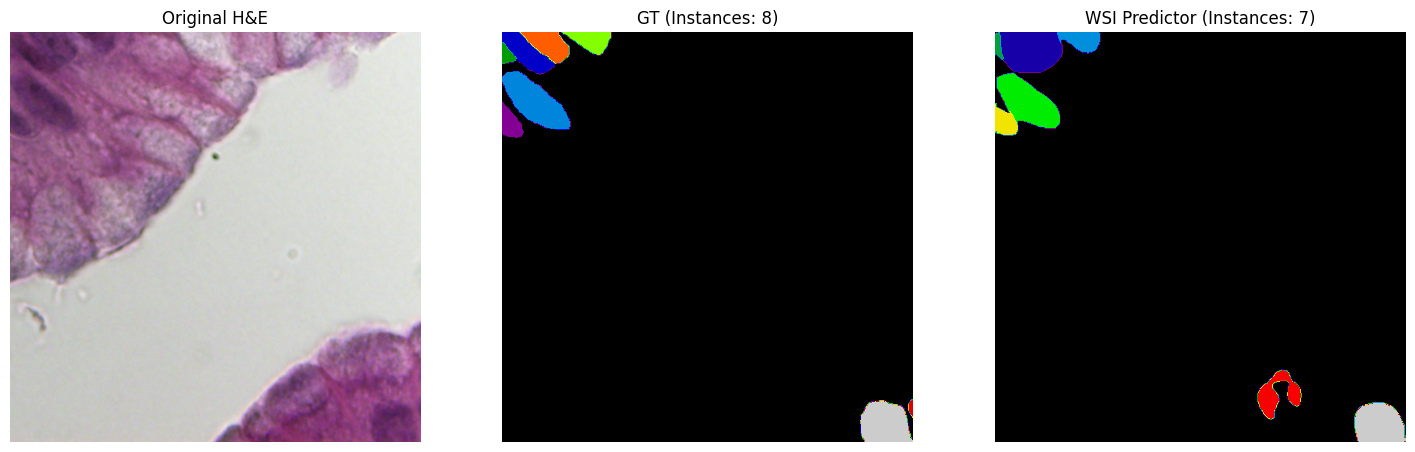

In [25]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tempfile
import os
import shutil
from PIL import Image
from vitaminp.inference import WSIPredictor

# 1. Logic to find the specific sample (as per your first code block)
he_dsb2018_samples = []
for batch in test_loader:
    sources = batch.get('dataset_source', [])
    for i, source in enumerate(sources):
        if source == 'he_dsb2018':
            he_dsb2018_samples.append((i, batch))
    if len(he_dsb2018_samples) >= 1: break

sample_idx, batch = he_dsb2018_samples[1]
original_img = batch['he_image'][sample_idx].permute(1, 2, 0).cpu().numpy()
gt_nuclei = batch['he_nuclei_instance'][sample_idx].cpu().numpy()

# 2. Prepare Temporary Workspace
temp_dir = tempfile.mkdtemp()
temp_image_path = os.path.join(temp_dir, 'sample_dsb2018.png')

# Convert to uint8 for PIL
img_uint8 = (original_img * 255).astype(np.uint8) if original_img.max() <= 1.0 else original_img.astype(np.uint8)
Image.fromarray(img_uint8).save(temp_image_path)

# 3. Initialize Predictor with your VitaminP model
predictor = WSIPredictor(
    model=model,
    device=device,
    patch_size=512,
    overlap=64,
    target_mpp=0.2125, # Standard for 20x magnification
    magnification=40,
    batch_size=1,
    tissue_dilation=1,
)

# 4. Run WSIPredictor Inference
print("🚀 Running WSIPredictor Inference...")
results = predictor.predict(
    wsi_path=temp_image_path,
    output_dir=os.path.join(temp_dir, 'output'),
    branches=['he_nuclei'], # DSB2018 usually focuses on nuclei
    filter_tissue=False,    
    clean_overlaps=True,
    save_geojson=False,
    save_parquet=False
)

# 5. Extract Results
inst_info = results['he_nuclei']['instances']
pred_mask = np.zeros(original_img.shape[:2], dtype=np.int32)

# Draw instances into a mask for comparison
for inst_id, data in inst_info.items():
    cv2.fillPoly(pred_mask, [data['contour']], int(inst_id))

# 6. Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(original_img)
axes[0].set_title("Original H&E")
axes[1].imshow(gt_nuclei, cmap='nipy_spectral')
axes[1].set_title(f"GT (Instances: {len(np.unique(gt_nuclei))-1})")
axes[2].imshow(pred_mask, cmap='nipy_spectral')
axes[2].set_title(f"WSI Predictor (Instances: {len(inst_info)})")

for ax in axes: ax.axis('off')
plt.show()

# Cleanup
shutil.rmtree(temp_dir)

In [28]:
import torch
import numpy as np
from tqdm import tqdm
from metrics import get_fast_pq, aggregated_jaccard_index, dice_coefficient
from vitaminp import VitaminPFlex
from vitaminp.inference import WSIPredictor
import tempfile
import os
from PIL import Image
import shutil
import cv2

# ==========================================
# 1. SETUP
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VitaminPFlex(model_size='large').to(device)
model.load_state_dict(torch.load("checkpoints/vitamin_p_flex_large_fold32_hv4_mag_best.pth", map_location=device))
model.eval()

predictor = WSIPredictor(
    model=model, device=device, patch_size=512, overlap=64,
    target_mpp=0.425, magnification=20, batch_size=8, tissue_dilation=1,
)

metrics = {
    'base': {'pq': [], 'aji': [], 'dice': []},
    'tta': {'pq': [], 'aji': [], 'dice': []}
}

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def inst_to_maps(inst_dict, shape):
    mask = np.zeros(shape, dtype=np.float32)
    inst_map = np.zeros(shape, dtype=np.int32)
    for inst_id, data in inst_dict.items():
        cv2.fillPoly(mask, [data['contour']], 1.0)
        cv2.fillPoly(inst_map, [data['contour']], int(inst_id))
    return mask, inst_map

def deaugment_contours(inst_raw, shape, flip_type='h'):
    deaug = {}
    h, w = shape[:2]
    for inst_id, data in inst_raw.items():
        contour = data['contour'].copy()
        centroid = data['centroid'].copy()
        if flip_type == 'h':
            contour[:, 0] = w - 1 - contour[:, 0]
            centroid[0] = w - 1 - centroid[0]
        elif flip_type == 'v':
            contour[:, 1] = h - 1 - contour[:, 1]
            centroid[1] = h - 1 - centroid[1]
        deaug[inst_id] = {'contour': contour, 'centroid': centroid}
    return deaug

# ==========================================
# 3. EVALUATION LOOP
# ==========================================
temp_dir = tempfile.mkdtemp()

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_loader, desc="DSB2018 TTA Eval")):
        sources = batch.get('dataset_source', [])
        for i, source in enumerate(sources):
            if source != 'he_dsb2018': continue

            # Get Data
            original = batch['he_image'][i].permute(1, 2, 0).cpu().numpy()
            gt_inst = batch['he_nuclei_instance'][i].cpu().numpy()
            gt_mask = (gt_inst > 0).astype(np.float32)
            img_uint8 = (original * 255).astype(np.uint8) if original.max() <= 1.0 else original.astype(np.uint8)

            # --- 1. BASE (Original) ---
            p_orig = os.path.join(temp_dir, 'orig.png')
            Image.fromarray(img_uint8).save(p_orig)
            res_orig = predictor.predict(wsi_path=p_orig, output_dir=os.path.join(temp_dir, 'out_o'), branches=['he_nuclei'], filter_tissue=False)['he_nuclei']['instances']
            
            # --- 2. H-FLIP ---
            p_h = os.path.join(temp_dir, 'hflip.png')
            Image.fromarray(np.fliplr(img_uint8)).save(p_h)
            res_h_raw = predictor.predict(wsi_path=p_h, output_dir=os.path.join(temp_dir, 'out_h'), branches=['he_nuclei'], filter_tissue=False)['he_nuclei']['instances']
            res_h = deaugment_contours(res_h_raw, img_uint8.shape, 'h')

            # --- 3. V-FLIP ---
            p_v = os.path.join(temp_dir, 'vflip.png')
            Image.fromarray(np.flipud(img_uint8)).save(p_v)
            res_v_raw = predictor.predict(wsi_path=p_v, output_dir=os.path.join(temp_dir, 'out_v'), branches=['he_nuclei'], filter_tissue=False)['he_nuclei']['instances']
            res_v = deaugment_contours(res_v_raw, img_uint8.shape, 'v')

            # --- CALCULATE METRICS ---
            if gt_inst.max() > 0:
                results_to_compare = [res_orig, res_h, res_v]
                sample_pqs, sample_ajis, sample_dices = [], [], []

                for idx, inst_dict in enumerate(results_to_compare):
                    m, im = inst_to_maps(inst_dict, original.shape[:2])
                    pq, _, _ = get_fast_pq(gt_inst, im)
                    aji = aggregated_jaccard_index(gt_inst, im)
                    dice_val = dice_coefficient(torch.from_numpy(m).unsqueeze(0), torch.from_numpy(gt_mask).unsqueeze(0))
                    dice = dice_val.item() if torch.is_tensor(dice_val) else dice_val
                    
                    sample_pqs.append(pq); sample_ajis.append(aji); sample_dices.append(dice)
                    
                    if idx == 0: # Store Base
                        metrics['base']['pq'].append(pq)
                        metrics['base']['aji'].append(aji)
                        metrics['base']['dice'].append(dice)

                # Store TTA (Mean of Augmentations)
                metrics['tta']['pq'].append(np.mean(sample_pqs))
                metrics['tta']['aji'].append(np.mean(sample_ajis))
                metrics['tta']['dice'].append(np.mean(sample_dices))

# ==========================================
# 4. REPORTING
# ==========================================
print("\n" + "="*80)
print(f"{'Metric':<10} | {'Base Mean':<12} | {'TTA Mean':<12} | {'Improvement'}")
print("-" * 80)
for m in ['pq', 'aji', 'dice']:
    b, t = np.mean(metrics['base'][m]), np.mean(metrics['tta'][m])
    print(f"{m.upper():<10} | {b:.4f}       | {t:.4f}       | {((t-b)/b)*100:+.2f}%")
shutil.rmtree(temp_dir)

✓ VitaminPFlex PRO initialized with large backbone
  + ASPP Bridge Active (Context Enhancement)
  + CoordConv Heads Active (Spatial Awareness)


2026-02-17 03:27:48 - WSIPredictor - INFO - WSIPredictor initialized:
2026-02-17 03:27:48 - WSIPredictor - INFO -   Device: cuda
2026-02-17 03:27:48 - WSIPredictor - INFO -   Model type: VitaminPFlex (single-modality)
2026-02-17 03:27:48 - WSIPredictor - INFO -   Batch Size: 8
DSB2018 TTA Eval:   0%|          | 0/28 [00:00<?, ?it/s]2026-02-17 03:27:49 - WSIPredictor - INFO - 🔍 Resolution: MPP=0.4250, scale=2.00x, Batch Size=8
2026-02-17 03:27:49 - WSIPredictor - INFO - 🧠 Running Batch Inference...


   Virtual upscaled size: 1024x1024 (from 512x512)
   Scanning 3x3 tile grid...



Processing: 100%|██████████| 9/9 [00:01<00:00,  6.34it/s]
2026-02-17 03:27:50 - WSIPredictor - INFO -    ✓ Extracted 126 instances (before cleaning)
2026-02-17 03:27:50 - WSIPredictor - INFO - 🧹 Cleaning overlapping instances at tile boundaries...
2026-02-17 03:27:50 - WSIPredictor - INFO -    🔍 Starting with 126 instances
2026-02-17 03:27:50 - WSIPredictor - INFO -    📍 Phase 1: Hard Drop (directional boundary cleaning)
2026-02-17 03:27:50 - WSIPredictor - INFO -    ✓ Hard Drop removed 23, survivors: 103
2026-02-17 03:27:50 - WSIPredictor - INFO -    🔄 Phase 2: Iterative overlap removal
2026-02-17 03:27:50 - WSIPredictor - INFO -       Iteration 1: 36 overlaps, kept 55/103
2026-02-17 03:27:50 - WSIPredictor - INFO -       Iteration 2: 3 overlaps, kept 52/55
2026-02-17 03:27:50 - WSIPredictor - INFO -       Iteration 3: 0 overlaps, kept 52/52
2026-02-17 03:27:50 - WSIPredictor - INFO -       ✓ Converged!
2026-02-17 03:27:50 - WSIPredictor - INFO -    ✅ Final count: 52 instances
2026-0

   Virtual upscaled size: 1024x1024 (from 512x512)
   Scanning 3x3 tile grid...


...

   Virtual upscaled size: 1024x1024 (from 512x512)
   Scanning 3x3 tile grid...



Processing: 100%|██████████| 9/9 [00:00<00:00, 10.51it/s]
2026-02-17 03:28:41 - WSIPredictor - INFO -    ✓ Extracted 20 instances (before cleaning)
2026-02-17 03:28:41 - WSIPredictor - INFO - 🧹 Cleaning overlapping instances at tile boundaries...
2026-02-17 03:28:41 - WSIPredictor - INFO -    🔍 Starting with 20 instances
2026-02-17 03:28:41 - WSIPredictor - INFO -    📍 Phase 1: Hard Drop (directional boundary cleaning)
2026-02-17 03:28:41 - WSIPredictor - INFO -    ✓ Hard Drop removed 3, survivors: 17
2026-02-17 03:28:41 - WSIPredictor - INFO -    🔄 Phase 2: Iterative overlap removal
2026-02-17 03:28:41 - WSIPredictor - INFO -       Iteration 1: 1 overlaps, kept 16/17
2026-02-17 03:28:41 - WSIPredictor - INFO -       Iteration 2: 0 overlaps, kept 16/16
2026-02-17 03:28:41 - WSIPredictor - INFO -       ✓ Converged!
2026-02-17 03:28:41 - WSIPredictor - INFO -    ✅ Final count: 16 instances
2026-02-17 03:28:41 - WSIPredictor - INFO -    ✓ Removed 4, remaining: 16
2026-02-17 03:28:41 - WS

   Virtual upscaled size: 1024x1024 (from 512x512)
   Scanning 3x3 tile grid...



Processing: 100%|██████████| 9/9 [00:00<00:00,  9.10it/s]
2026-02-17 03:28:43 - WSIPredictor - INFO -    ✓ Extracted 78 instances (before cleaning)
2026-02-17 03:28:43 - WSIPredictor - INFO - 🧹 Cleaning overlapping instances at tile boundaries...
2026-02-17 03:28:43 - WSIPredictor - INFO -    🔍 Starting with 78 instances
2026-02-17 03:28:43 - WSIPredictor - INFO -    📍 Phase 1: Hard Drop (directional boundary cleaning)
2026-02-17 03:28:43 - WSIPredictor - INFO -    ✓ Hard Drop removed 0, survivors: 78
2026-02-17 03:28:43 - WSIPredictor - INFO -    🔄 Phase 2: Iterative overlap removal
2026-02-17 03:28:43 - WSIPredictor - INFO -       Iteration 1: 20 overlaps, kept 30/78
2026-02-17 03:28:43 - WSIPredictor - INFO -       Iteration 2: 3 overlaps, kept 19/30
2026-02-17 03:28:43 - WSIPredictor - INFO -       Iteration 3: 0 overlaps, kept 19/19
2026-02-17 03:28:43 - WSIPredictor - INFO -       ✓ Converged!
2026-02-17 03:28:43 - WSIPredictor - INFO -    ✅ Final count: 19 instances
2026-02-17 


Metric     | Base Mean    | TTA Mean     | Improvement
--------------------------------------------------------------------------------
PQ         | 0.4250       | 0.4203       | -1.09%
AJI        | 0.4441       | 0.4476       | +0.78%
DICE       | 0.7479       | 0.7542       | +0.84%


## mIF DSB2018

🎲 Selected Random Index: 50
🖼️ Sample Name: fluorescence_a984e7fb886aa02e29d112766d3ce26a4f78eac540ce7bbdbd42af2761928f6d


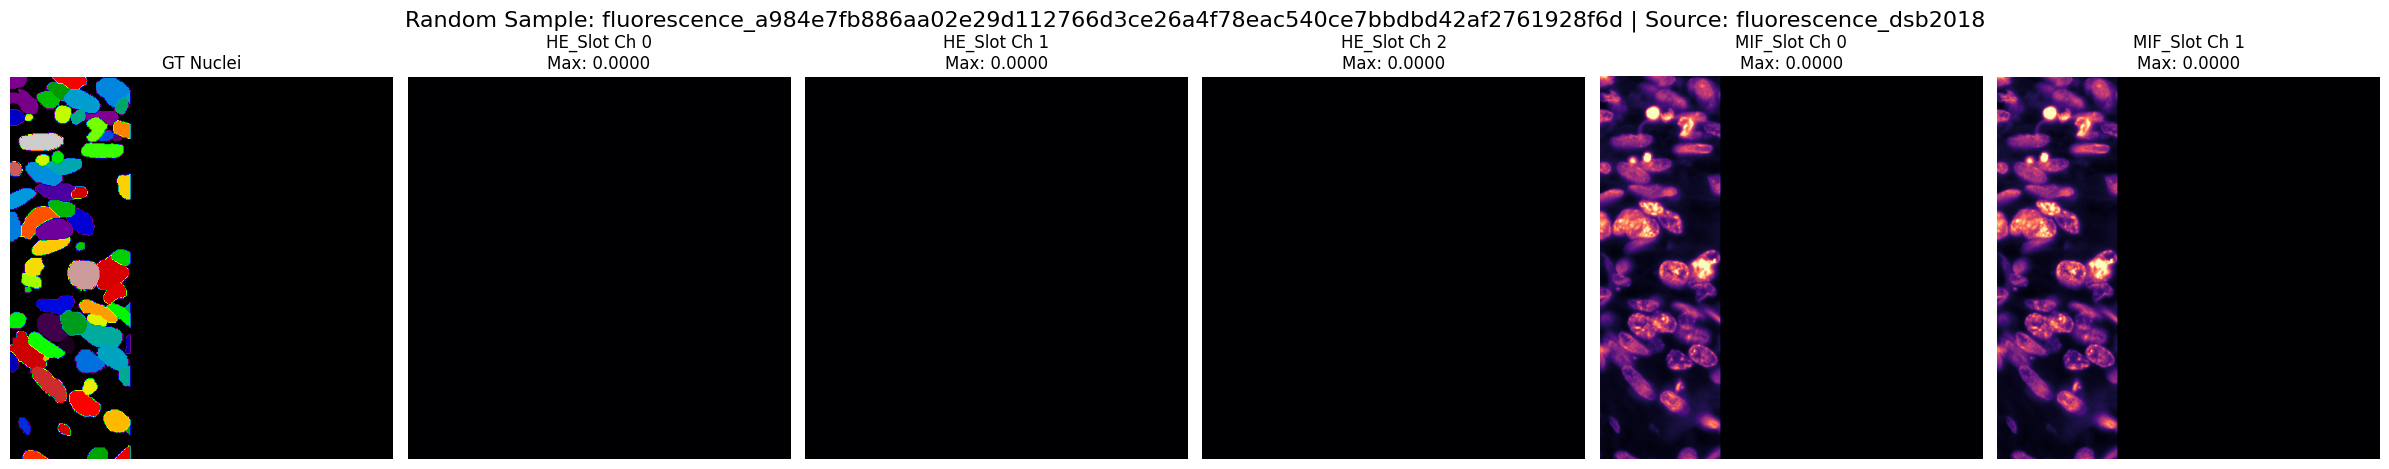


📊 Channel Max Values:
HE  -> Ch0: 0.0000 | Ch1: 0.0000 | Ch2: 0.0000
MIF -> Ch0: 0.0000 | Ch1: 0.0000


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. FIND ALL INDICES FOR THIS SOURCE
# ==========================================
target_source = 'fluorescence_dsb2018'
all_target_indices = []

# We'll look through the dataset patch info directly to find all matches
for idx, info in enumerate(test_loader.dataset.patch_info):
    sample_name = info[0]
    if sample_name.startswith(target_source):
        all_target_indices.append(idx)

if not all_target_indices:
    print(f"❌ No samples found for {target_source}")
else:
    # 2. PICK A RANDOM ONE
    random_idx = random.choice(all_target_indices)
    sample_data = test_loader.dataset[random_idx]
    
    print(f"🎲 Selected Random Index: {random_idx}")
    print(f"🖼️ Sample Name: {sample_data['sample_name']}")
    
    # ==========================================
    # 3. VISUALIZE RAW SLOTS
    # ==========================================
    # We show: GT, HE Ch0-2, and MIF Ch0-1
    fig, axes = plt.subplots(1, 6, figsize=(24, 5))
    plt.suptitle(f"Random Sample: {sample_data['sample_name']} | Source: {sample_data['dataset_source']}", fontsize=16)

    # Reference GT
    gt = sample_data['mif_nuclei_instance'].cpu().numpy()
    axes[0].imshow(gt, cmap='nipy_spectral')
    axes[0].set_title("GT Nuclei")

    # HE Slots (Check here if MIF is empty)
    he_img = sample_data['he_image'].cpu().numpy()
    for c in range(3):
        ch_data = he_img[c]
        axes[c+1].imshow(ch_data, cmap='magma')
        axes[c+1].set_title(f"HE_Slot Ch {c}\nMax: {ch_data.max():.4f}")

    # MIF Slots (Check here)
    mif_img = sample_data['mif_image'].cpu().numpy()
    for c in range(2):
        ch_data = mif_img[c]
        axes[c+4].imshow(ch_data, cmap='magma')
        axes[c+4].set_title(f"MIF_Slot Ch {c}\nMax: {ch_data.max():.4f}")

    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Log the stats
    print(f"\n📊 Channel Max Values:")
    print(f"HE  -> Ch0: {he_img[0].max():.4f} | Ch1: {he_img[1].max():.4f} | Ch2: {he_img[2].max():.4f}")
    print(f"MIF -> Ch0: {mif_img[0].max():.4f} | Ch1: {mif_img[1].max():.4f}")

2026-02-17 03:55:13 - WSIPredictor - INFO - WSIPredictor initialized:
2026-02-17 03:55:13 - WSIPredictor - INFO -   Device: cuda
2026-02-17 03:55:13 - WSIPredictor - INFO -   Model type: VitaminPFlex (single-modality)
2026-02-17 03:55:13 - WSIPredictor - INFO -   Batch Size: 1
2026-02-17 03:55:13 - WSIPredictor - INFO -   MIF Config: Present
2026-02-17 03:55:13 - WSIPredictor - INFO - 🔍 Resolution: MPP=0.4250, scale=2.00x, Batch Size=1
2026-02-17 03:55:13 - WSIPredictor - INFO - 🧠 Running Batch Inference...


⚠️ Boosting low intensity signal (Max was 0.0000)

📝 IMAGE INFO: fluorescence_7f4cbe0b36b5d09466476a7d4e01f4f976c67872d549f4ff47b3e1e3a2b403af (from MIF Slot)
Channel 0: Max=0.9993, Mean=0.0176
Channel 1: Max=0.9993, Mean=0.0176

   Virtual upscaled size: 4x1024 (from 2x512)
   Scanning 0x3 tile grid...


Processing: 0it [00:00, ?it/s]
2026-02-17 03:55:13 - WSIPredictor - INFO -    ✓ Extracted 0 instances (before cleaning)
2026-02-17 03:55:13 - WSIPredictor - INFO - ✅ mif_nuclei: 0 detections


Output: shape=(2, 512, 512), dtype=float32, range=[0.000, 0.999]


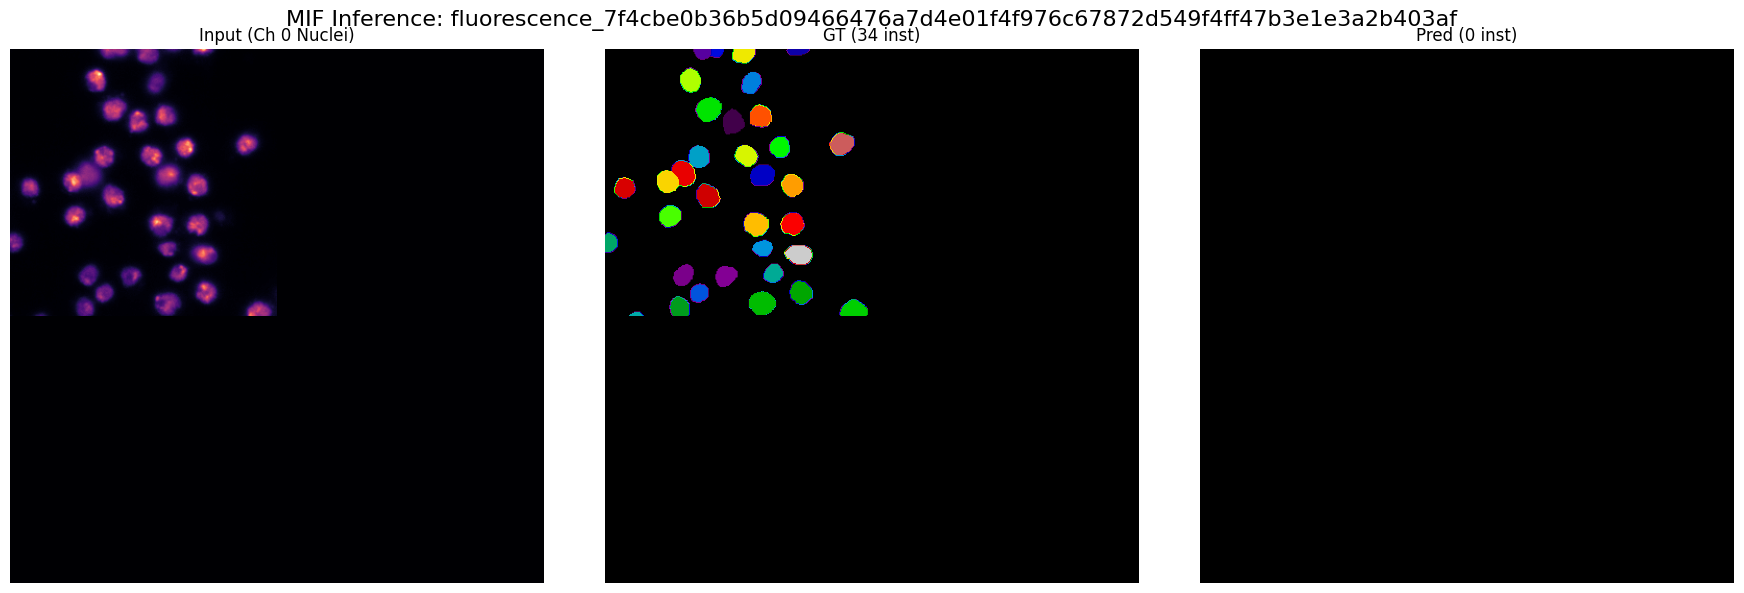

In [12]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tempfile
import os
import shutil
import random
import tifffile
from vitaminp import VitaminPFlex
from vitaminp.inference import WSIPredictor
from vitaminp.inference.channel_config import ChannelConfig

# ==========================================
# 1. SETUP & MODEL
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint_path = "checkpoints/vitamin_p_flex_large_fold32_hv4_mag_best.pth"

if 'model' not in locals():
    print("📦 Loading VitaminP model...")
    model = VitaminPFlex(model_size='large').to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

mif_config = ChannelConfig(
    nuclear_channel=0,
    membrane_channel=1,
    channel_names={0: 'Nuclei', 1: 'Cell'}
)

# ==========================================
# 2. SELECT RANDOM SAMPLE
# ==========================================
target_source = 'fluorescence_dsb2018'
all_indices = [idx for idx, info in enumerate(test_loader.dataset.patch_info) 
               if info[0].startswith(target_source)]

if not all_indices:
    raise ValueError(f"❌ No samples found for {target_source}")

random_idx = random.choice(all_indices)
sample_data = test_loader.dataset[random_idx]

# 🟢 FIX: Check both slots for data. If HE is empty, check MIF.
he_part = sample_data['he_image'][:2].cpu().numpy()
mif_part = sample_data['mif_image'][:2].cpu().numpy()

if he_part.max() > mif_part.max():
    mif_raw = he_part
    slot_used = "HE Slot"
else:
    mif_raw = mif_part
    slot_used = "MIF Slot"

# 🟢 FIX: Rescale if values are crushed (e.g., max is 0.0032)
# VitaminP needs signal in the 0.0-1.0 range, not buried at 0.001
if mif_raw.max() > 0 and mif_raw.max() < 0.1:
    print(f"⚠️ Boosting low intensity signal (Max was {mif_raw.max():.4f})")
    mif_raw = mif_raw / (mif_raw.max() + 1e-8)

gt_nuclei = sample_data['mif_nuclei_instance'].cpu().numpy()

# 📊 PRINT RAW IMAGE INFO
print(f"\n📝 IMAGE INFO: {sample_data['sample_name']} (from {slot_used})")
print(f"{'='*30}")
for c in range(mif_raw.shape[0]):
    print(f"Channel {c}: Max={mif_raw[c].max():.4f}, Mean={mif_raw[c].mean():.4f}")
print(f"{'='*30}\n")

# ==========================================
# 3. RUN INFERENCE
# ==========================================
temp_dir = tempfile.mkdtemp()
temp_tiff_path = os.path.join(temp_dir, 'sample.tif')
tifffile.imwrite(temp_tiff_path, mif_raw, imagej=True)

predictor = WSIPredictor(
    model=model, device=device, patch_size=512, overlap=64,
    target_mpp=0.425, magnification=20,
    mif_channel_config=mif_config, batch_size=1
)

results = predictor.predict(
    wsi_path=temp_tiff_path,
    output_dir=os.path.join(temp_dir, 'output'),
    branches=['mif_nuclei'], 
    filter_tissue=False
)

# ==========================================
# 4. VISUALIZE
# ==========================================
nuc_info = results['mif_nuclei']['instances']
pred_mask = np.zeros(mif_raw.shape[1:], dtype=np.int32)

for inst_id, data in nuc_info.items():
    cv2.fillPoly(pred_mask, [data['contour']], int(inst_id))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.suptitle(f"MIF Inference: {sample_data['sample_name']}", fontsize=16)

# Raw Input (now boosted if it was black)
axes[0].imshow(mif_raw[0], cmap='magma')
axes[0].set_title(f"Input (Ch 0 Nuclei)")

axes[1].imshow(gt_nuclei, cmap='nipy_spectral')
axes[1].set_title(f"GT ({len(np.unique(gt_nuclei))-1} inst)")

axes[2].imshow(pred_mask, cmap='nipy_spectral')
axes[2].set_title(f"Pred ({len(nuc_info)} inst)")

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

shutil.rmtree(temp_dir)

📊 VERIFICATION FOR: fluorescence_1ef68e93964c2d9230100c1347c328f6385a7bc027879dc3d4c055e6fe80cb3c
Shape: (2, 512, 512)
Channel 0: Max=0.0000, Mean=0.0000 -> ❌ TOO DARK/EMPTY
Channel 1: Max=0.0000, Mean=0.0000 -> ❌ TOO DARK/EMPTY


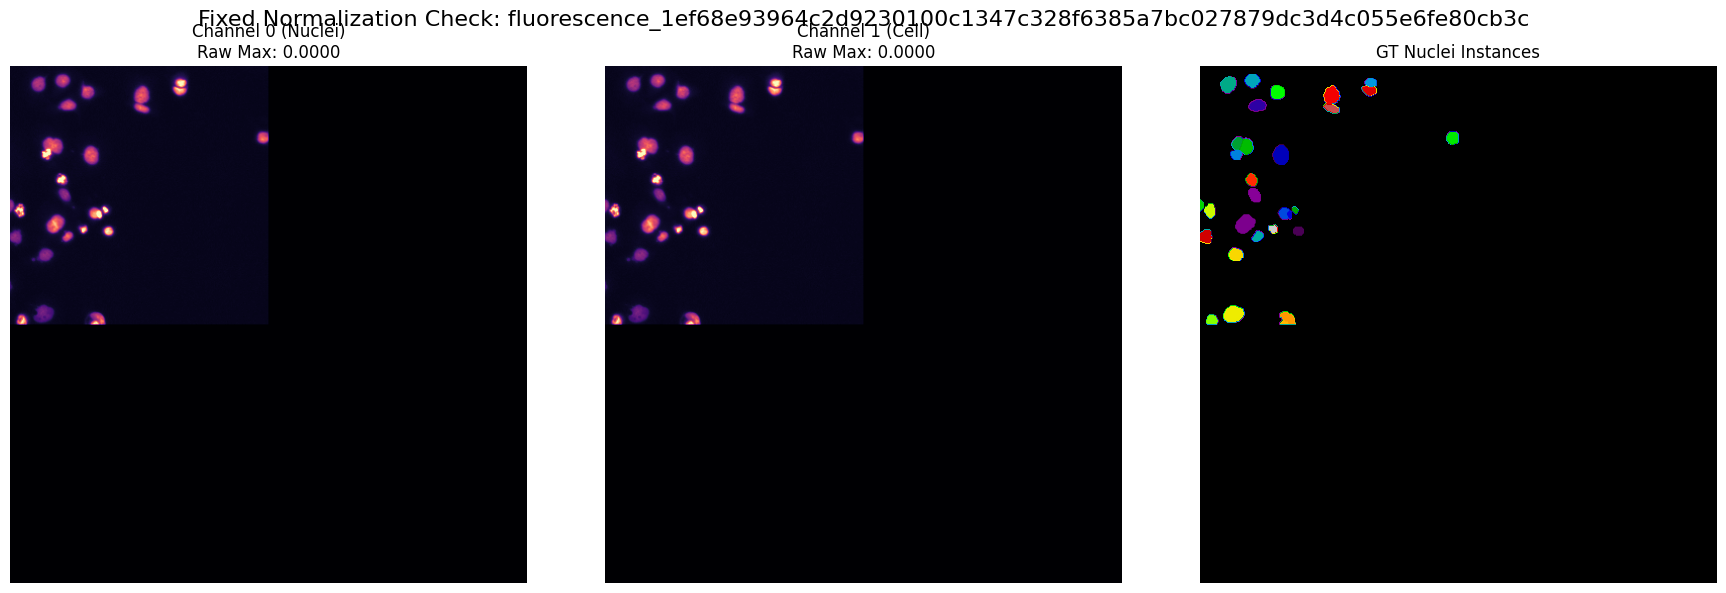

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. GRAB A RANDOM PROCESSED SAMPLE
# ==========================================
target_source = 'fluorescence_dsb2018'
all_indices = [idx for idx, info in enumerate(test_loader.dataset.patch_info) 
               if info[0].startswith(target_source)]

random_idx = random.choice(all_indices)
# This calls your __getitem__ which now has the fix
sample_data = test_loader.dataset[random_idx]

# ==========================================
# 2. CHECK THE STATS (THE TRUTH)
# ==========================================
mif_tensor = sample_data['mif_image'] # Already (C, H, W) and float32
mif_np = mif_tensor.cpu().numpy()

print(f"📊 VERIFICATION FOR: {sample_data['sample_name']}")
print(f"{'='*40}")
print(f"Shape: {mif_np.shape}")
for c in range(mif_np.shape[0]):
    c_max = mif_np[c].max()
    c_mean = mif_np[c].mean()
    status = "✅ VISIBLE" if c_max > 0.1 else "❌ TOO DARK/EMPTY"
    print(f"Channel {c}: Max={c_max:.4f}, Mean={c_mean:.4f} -> {status}")
print(f"{'='*40}")

# ==========================================
# 3. VISUALIZE WITHOUT ANY EXTRA STRETCHING
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.suptitle(f"Fixed Normalization Check: {sample_data['sample_name']}", fontsize=16)

# Channel 0 (Nuclei)
axes[0].imshow(mif_np[0], cmap='magma')
axes[0].set_title(f"Channel 0 (Nuclei)\nRaw Max: {mif_np[0].max():.4f}")

# Channel 1 (Cell/Membrane)
axes[1].imshow(mif_np[1], cmap='magma')
axes[1].set_title(f"Channel 1 (Cell)\nRaw Max: {mif_np[1].max():.4f}")

# GT Reference
gt = sample_data['mif_nuclei_instance'].cpu().numpy()
axes[2].imshow(gt, cmap='nipy_spectral')
axes[2].set_title("GT Nuclei Instances")

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()